Using device: cuda
Total images: 60


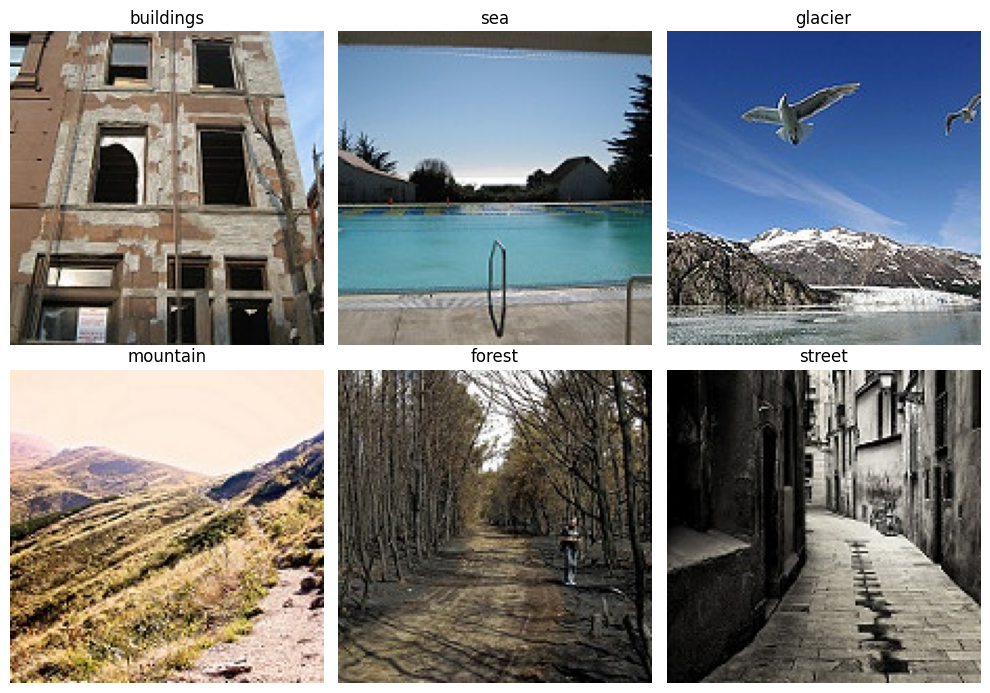

ResNet18 params: 11689512
Processed: 60
Overall mean confidence: 0.41947648823261263
buildings 0.2889078386127949
forest 0.2476579338312149
glacier 0.4993327036499977
mountain 0.55556211322546
sea 0.5710343837738037
street 0.3543639563024044


/tmp/ipykernel_58/2308024433.py:129: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=LABELS)


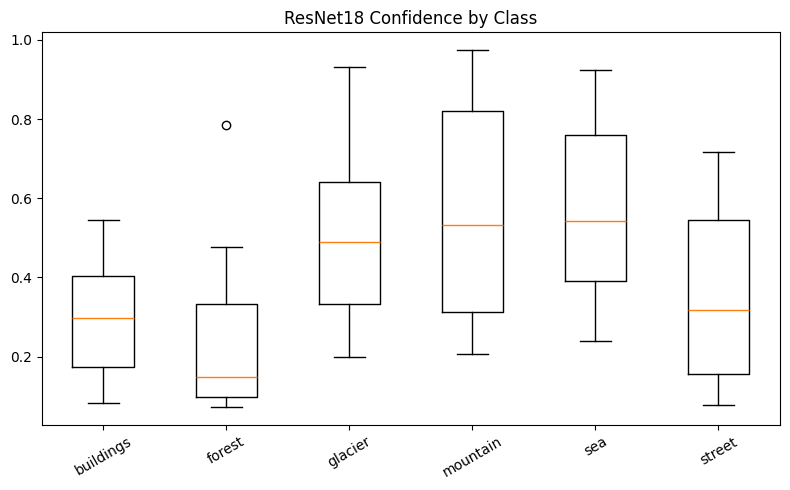

ResNet18 11689512
MobileNetV3 2542856
EfficientNetB0 5288548


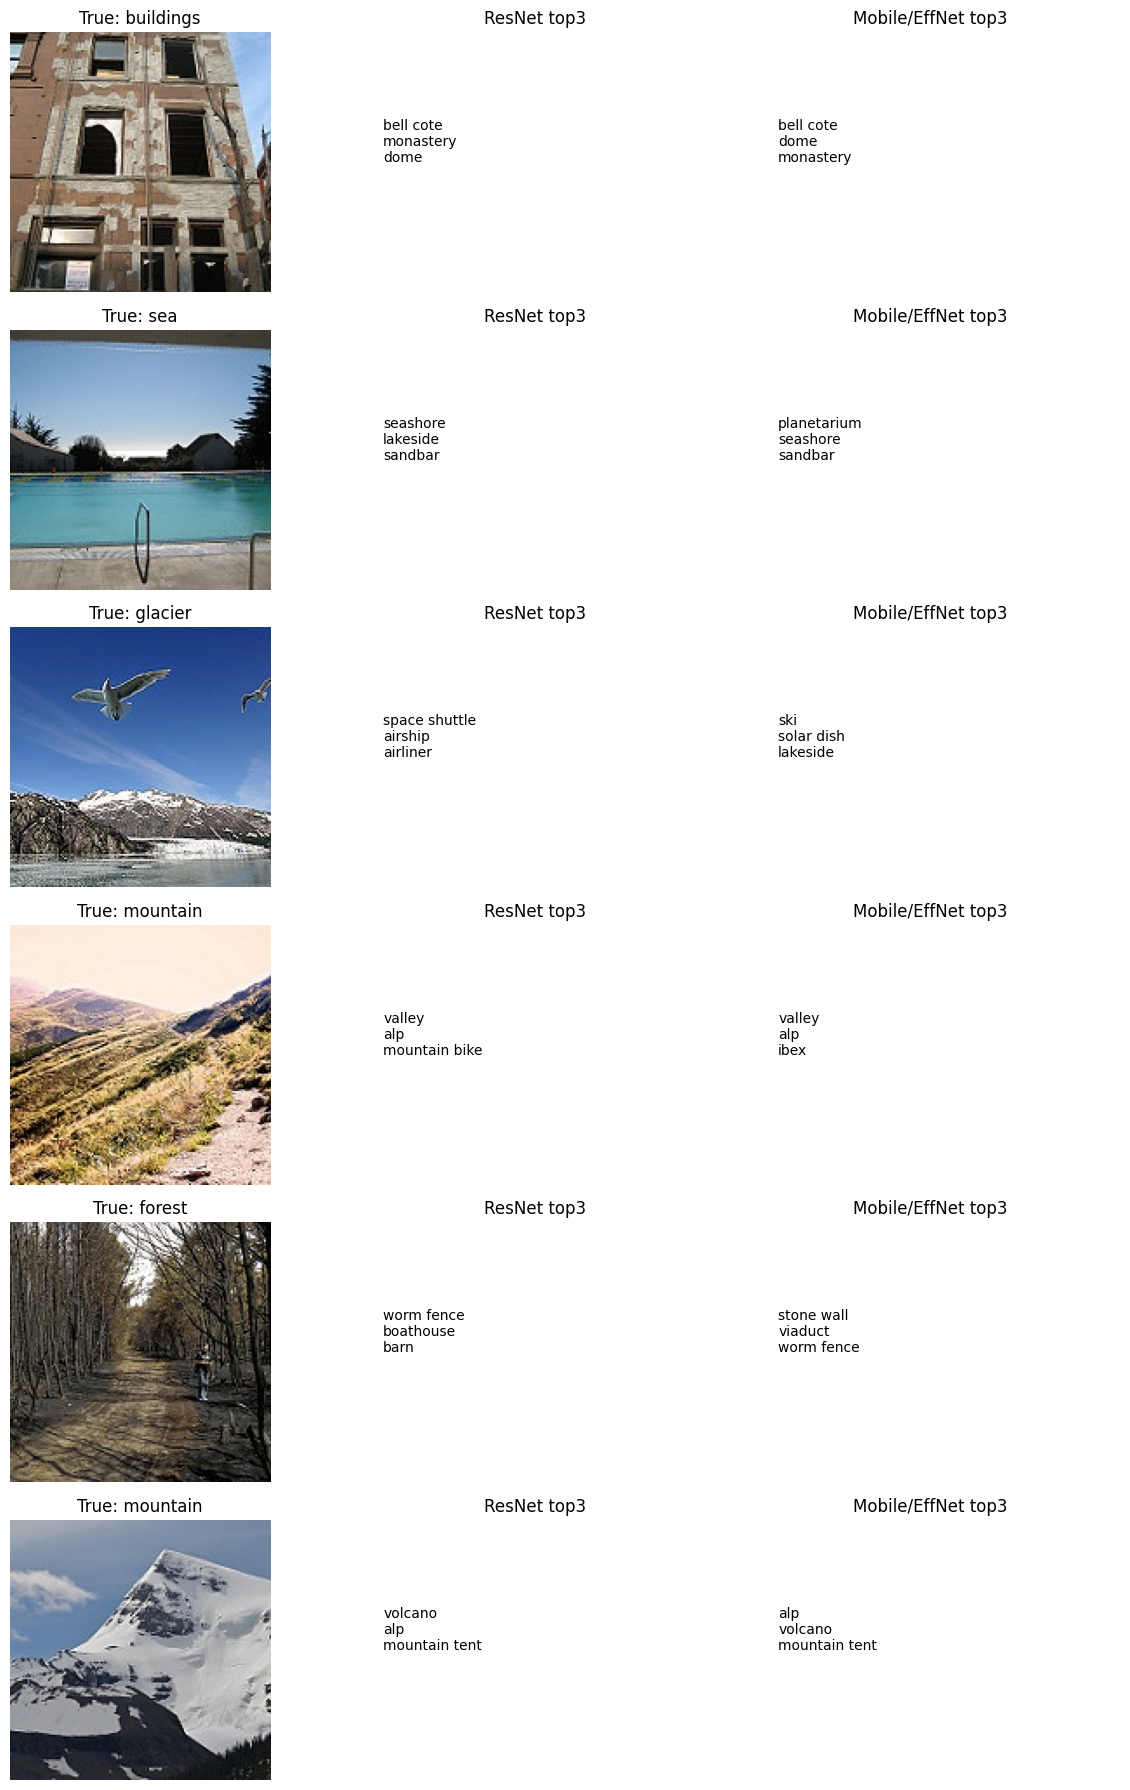

5.811842282613119 8.94229014714559 12.804214159647625


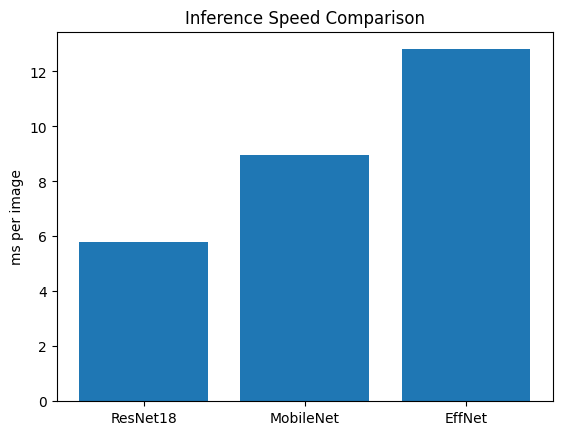

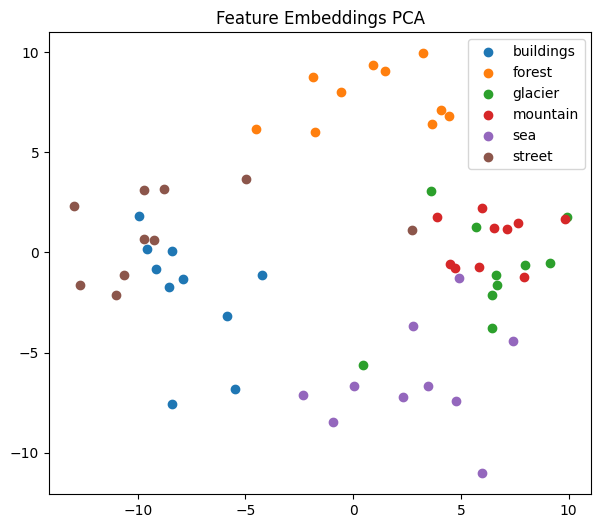

In [2]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

random.seed(42)


def load_images(n_per_class=10):
    image_set = []
    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = list(class_dir.glob("*.jpg"))
        paths = random.sample(paths, min(n_per_class, len(paths)))

        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))

    random.shuffle(image_set)
    return image_set


image_set = load_images(10)
print("Total images:", len(image_set))



# SAMPLE GRID (2x3)

fig, axes = plt.subplots(2, 3, figsize=(10, 7))

seen = set()
idx = 0

for i in range(2):
    for j in range(3):
        while image_set[idx][1] in seen:
            idx += 1
        img, label = image_set[idx]
        seen.add(label)

        axes[i, j].imshow(img)
        axes[i, j].set_title(label)
        axes[i, j].axis("off")

        idx += 1

plt.tight_layout()
plt.savefig("outputs/dataset_sample.png")
plt.show()


resnet_weights = ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print("ResNet18 params:", sum(p.numel() for p in resnet.parameters()))


def run_inference(model, preprocess, img, device, class_names, top_k=5):
    tensor = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.nn.functional.softmax(logits, dim=1)[0]

    top_probs, top_idxs = torch.topk(probs, top_k)

    return [
        (class_names[i], float(p))
        for p, i in zip(top_probs, top_idxs)
    ]

resnet_results = []

for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)

    resnet_results.append({
        "true_label": true_label,
        "top1_class": preds[0][0],
        "top1_prob": preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs": [p[1] for p in preds],
    })

print("Processed:", len(resnet_results))


from collections import defaultdict

by_class = defaultdict(list)

for r in resnet_results:
    by_class[r["true_label"]].append(r["top1_prob"])

mean_overall = np.mean([r["top1_prob"] for r in resnet_results])
print("Overall mean confidence:", mean_overall)

for c in LABELS:
    print(c, np.mean(by_class[c]))

plt.figure(figsize=(8,5))

data = [by_class[c] for c in LABELS]
plt.boxplot(data, labels=LABELS)

plt.title("ResNet18 Confidence by Class")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("outputs/resnet18_confidence_by_class.png")
plt.show()


mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

for name, m in [
    ("ResNet18", resnet),
    ("MobileNetV3", mobilenet),
    ("EfficientNetB0", efficientnet)
]:
    print(name, sum(p.numel() for p in m.parameters()))


def run_model(model, preprocess, results_list, class_names):
    out = []
    for img, true_label in image_set:
        preds = run_inference(model, preprocess, img, device, class_names)

        out.append({
            "true_label": true_label,
            "top1": preds[0][0],
            "top1_prob": preds[0][1],
            "top3": preds[:3]
        })
    return out


mobilenet_results = run_model(mobilenet, mobile_preproc, [], imagenet_classes)
effnet_results = run_model(efficientnet, effnet_preproc, [], imagenet_classes)


fig, axes = plt.subplots(6, 3, figsize=(12, 18))

for i in range(6):
    img, label = image_set[i]

    res_p = run_inference(resnet, resnet_preproc, img, device, imagenet_classes, 3)
    mob_p = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes, 3)
    eff_p = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes, 3)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"True: {label}")
    axes[i, 0].axis("off")

    axes[i, 1].set_title("ResNet top3")
    axes[i, 1].text(0.1, 0.5, "\n".join([f"{p[0]}" for p in res_p]))
    axes[i, 1].axis("off")

    axes[i, 2].set_title("Mobile/EffNet top3")
    axes[i, 2].text(0.1, 0.5, "\n".join([f"{p[0]}" for p in mob_p]))
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("outputs/model_comparison_grid.png")
plt.show()



def benchmark_model(model, preprocess, image_set, device, n_warmup=5):

    for img, _ in image_set[:n_warmup]:
        x = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(x)

    torch.cuda.synchronize()
    start = time.time()

    for img, _ in image_set:
        x = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(x)

    torch.cuda.synchronize()
    return ((time.time() - start) / len(image_set)) * 1000


resnet_ms = benchmark_model(resnet, resnet_preproc, image_set, device)
mobile_ms = benchmark_model(mobilenet, mobile_preproc, image_set, device)
effnet_ms = benchmark_model(efficientnet, effnet_preproc, image_set, device)

print(resnet_ms, mobile_ms, effnet_ms)


plt.bar(
    ["ResNet18", "MobileNet", "EffNet"],
    [resnet_ms, mobile_ms, effnet_ms]
)

plt.ylabel("ms per image")
plt.title("Inference Speed Comparison")
plt.savefig("outputs/inference_speed.png")
plt.show()


feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()
feature_extractor = feature_extractor.to(device).eval()

def extract_features(model, preprocess, img):
    x = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        f = model(x)
    return f.squeeze().cpu().numpy()

features = []
labels = []

for img, label in image_set:
    features.append(extract_features(feature_extractor, resnet_preproc, img))
    labels.append(label)

features = np.array(features)

pca = PCA(n_components=2)
f2 = pca.fit_transform(features)

plt.figure(figsize=(7,6))

for i, c in enumerate(LABELS):
    mask = np.array(labels) == c
    plt.scatter(f2[mask,0], f2[mask,1], label=c)

plt.legend()
plt.title("Feature Embeddings PCA")
plt.savefig("outputs/feature_embeddings.png")
plt.show()

def load_sample_image(label):
    paths = list((DATA_DIR/label).glob("*.jpg"))
    return Image.open(random.choice(paths)).convert("RGB"), label